# ITC feed-back minus analysis — the combined rate ladder

This notebook reads the 24 `itcfbm` minus runs together with the main set's
bumped runs and answers the pre-registered minimality question: how far below
the calculated headline ITC does trajectory delivery survive?

The combined ladder has five rungs per (arm, world):

- **p01** — the main set's fed rate, `i_model_headline + 0.01` (the
  indifference bump; runs `itcfb_fbB/fbC_{world}_p50`).
- **m01, m05, m10, m15** — the minus rungs, `i_model_headline - d` for
  d = 0.01, 0.05, 0.10, 0.15 (runs `itcfbm_fbBm/fbCm{dd}_{world}_p50`).

Worlds: aj, mck, eo — the three full-span schedules that all reproduce the
trajectory at the headline rate, so the decrements isolate the rate effect.
The three fbR flat-credit runs (0 / 30% / 50%, both technologies) anchor the
demand curve from below. No minus run has a mandate.

**Pre-registered claim separation (`run_manifest_minus.md`, verbatim).**
The runs test TRAJECTORY-DELIVERY minimality only. Marginal-breakeven
minimality of the duals is LP duality, already verified in-model by the rc=0
reduced-cost check, and is NOT at stake: a below-headline run that still
delivers the trajectory shows the headline (a max-region uniform rate) was
not delivery-minimal — the t13 overshoot materializing in deployment space —
not that the duals were wrong.

Reading order:

1. **R1 — the rate ladder** and its placement against the monetized-parity
   anchor.
2. **R2 — delivery trajectories down the ladder**, per arm and world.
3. **R3 — outcome classification and the delivery-minimality verdicts** (the
   ST9 feed).
4. **R4 — the deployment-vs-rate cliff**, extending the main set's q06 curve.
5. **R5 — the ignition cushion**: what endogenous learning adds or removes
   below the convex minimum (fbCm vs fbBm).
6. **R6 — substitution and context.**

Data-source discipline: gap tables and outcome classifications come from
`itcfbm_checks/exports/` and `itcfb_checks/exports/`, never re-derived; fed
rates come from the audited incentives-file echoes; the h5 files are read
only for capacity series. Run `itcfbm_checks/itcfbm_output_checks.ipynb`
first: R0 gates on both check registries.

Run on the **playground-env** kernel. Requires drive D.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)

HERE = Path.cwd()
assert HERE.name == "itcfbm_analysis", f"run from z-ethan/itcfbm_analysis/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
CHECKSM = REPO / "z-ethan" / "itcfbm_checks" / "exports"
CHECKSFB = REPO / "z-ethan" / "itcfb_checks" / "exports"
FB_ANALYSIS = REPO / "z-ethan" / "itcfb_analysis" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"
ITCFEED = REPO / "z-ethan" / "itc_feedback"

H5_DIR = Path("D:/ReEDS files/nuclear-learning/All runs so far")

# ---- case matrix ------------------------------------------------------------------
cases = pd.read_csv(REPO / "cases_nuclearlearning_itcfbm.csv", index_col=0)
CASES = [c for c in cases.columns if c != "Default Value"]
assert len(CASES) == 24, len(CASES)

WORLDS = ["aj", "mck", "eo"]      # ordered by 2050 ambition
SCHED_LABEL = {"aj": "Abou-Jaoude (134 GW)", "mck": "McKinsey (200 GW)",
               "eo": "EO 2025 (400 GW)"}
DECS = {"m01": 0.01, "m05": 0.05, "m10": 0.10, "m15": 0.15}
LADDER = ["m15", "m10", "m05", "m01", "p01"]      # deep to shallow; p01 = main set
CUT = {"m15": 0.15, "m10": 0.10, "m05": 0.05, "m01": 0.01, "p01": -0.01}
RUNG_LABEL = {"p01": "headline +0.01 (main set)", "m01": "headline −0.01",
              "m05": "headline −0.05", "m10": "headline −0.10",
              "m15": "headline −0.15"}

def parse_case(c):
    tok, world = c.split("_")[0], c.split("_")[1]
    return tok[:-2], "m" + tok[-2:], world      # (arm, rung, world)

META = {c: dict(zip(("arm", "rung", "world"), parse_case(c))) for c in CASES}
ARM_CASES = {a: [c for c in CASES if META[c]["arm"] == a] for a in ["fbBm", "fbCm"]}

def run_of(arm, rung, world):
    """Map an (arm, rung, world) ladder cell to its run name. The p01 rung is
    the main-set sibling: fbBm -> fbB, fbCm -> fbC."""
    if rung == "p01":
        return f"{arm[:-1]}_{world}_p50"
    return f"{arm}{rung[1:]}_{world}_p50"

SIBLING_CASES = sorted({run_of(a, "p01", w) for a in ARM_CASES for w in WORLDS})
FLAT_CASES = ["fbR_none", "fbR_itc30", "fbR_itc50"]
BASE_OF_WORLD = {w: f"smr100_{w}_p50" for w in WORLDS}

H5 = {c: H5_DIR / f"itcfbm_{c}_outputs.h5" for c in CASES}
for s in SIBLING_CASES + FLAT_CASES:
    H5[s] = H5_DIR / f"itcfb_{s}_outputs.h5"
for w in WORLDS:
    H5[BASE_OF_WORLD[w]] = H5_DIR / f"test1_{BASE_OF_WORLD[w]}_outputs.h5"

# ---- self-contained outputs.h5 reader (no `reeds` import: env/DLL constraints) --
_CACHE = {}

def load(case, key):
    if (case, key) in _CACHE:
        return _CACHE[(case, key)]
    with h5py.File(H5[case], "r") as f:
        if key not in f:
            raise KeyError(f"{key} not in {H5[case].name}")
        g = f[key]
        cols = [c.decode() for c in g["columns"][:]]
        data = {}
        for c in cols:
            arr = g[c][:]
            data[c] = arr.astype(str) if arr.dtype.kind == "S" else arr
        df = pd.DataFrame(data)[cols]
    for c in ("t", "allt"):
        if c in df.columns:
            df[c] = df[c].astype(int)
    _CACHE[(case, key)] = df
    return df


In [2]:
# ---- house figure style: z-ethan/plotstyle.py is the normative standard -----------
import sys

sys.path.insert(0, str(HERE.parent))
import plotstyle as ps

ps.apply()
COL = ps.COL
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT,
                                              ps.GRID_C, ps.EDGE_C, ps.SURFACE)
assert all(w in ps.SCHED_ORDER for w in WORLDS), \
    "world tokens diverged from plotstyle.SCHED_ORDER"
SCHED_C = dict(ps.SCHED_C)
# rung shading: one alpha per ladder position, deep rungs faint
RUNG_ALPHA = {"m15": 0.30, "m10": 0.45, "m05": 0.62, "m01": 0.82, "p01": 1.0}

def savefig(fig, name):
    return ps.savefig(fig, FIGURES / name)


## R0 — Data assembly, QA gate, and freshness

The QA gate: both check registries must show zero FAIL in phases A, B, and D
(file health, credit application, cross-case integrity). Phase C of the minus
checks holds the delivery outcomes; those rows are INFO by design and are
interpreted below.

In [3]:
summ_m = pd.read_csv(CHECKSM / "checks_summary.csv")
summ_fb = pd.read_csv(CHECKSFB / "checks_summary.csv")
for name, s in [("itcfbm_checks", summ_m), ("itcfb_checks", summ_fb)]:
    hard = s[(s["status"] == "FAIL") & s["phase"].isin(["A", "B", "D"])]
    assert not len(hard), f"mechanical-integrity FAILs in {name}:\n{hard}"
    c_fails = s[(s["status"] == "FAIL") & (s["phase"] == "C")]
    if len(c_fails):
        print(f"{name}: pre-registered phase-C FAILs (findings, not blockers):")
        print(c_fails[["check", "detail"]].to_string(index=False))
    else:
        print(f"{name}: no phase-C failures")

# gap tables + outcome classification from the checks (never re-derived)
GAPS_M = pd.read_csv(CHECKSM / "trajectory_gaps.csv")
OUT_M = pd.read_csv(CHECKSM / "delivery_outcomes.csv")
GAPS_FB = pd.read_csv(CHECKSFB / "trajectory_gaps.csv")
Q06 = pd.read_csv(FB_ANALYSIS / "q06_rate_deployment.csv")
PARITY = pd.read_csv(ITCFEED / "budget_parity_context.csv")

# fed rates: the audited incentives-file echoes (file ground truth)
ECHO_M = pd.read_csv(CHECKSM / "incentives_echo.csv")      # world, rung, t, itc_frac_file
ECHO_FB = pd.read_csv(CHECKSFB / "incentives_echo.csv")    # world, t, itc_frac_file
assert (ECHO_M["itc_frac_file"] == ECHO_M["itc_frac_expected"]).all()
assert (ECHO_FB["itc_frac_file"] == ECHO_FB["itc_frac_expected"]).all()
PEN = 0.1
FED = {}         # (world, rung) -> {t: itc_frac}
for w in WORLDS:
    for g in DECS:
        sub = ECHO_M[(ECHO_M["world"] == w) & (ECHO_M["rung"] == g)]
        FED[(w, g)] = dict(zip(sub["t"], sub["itc_frac_file"]))
    sub = ECHO_FB[ECHO_FB["world"] == w]
    FED[(w, "p01")] = dict(zip(sub["t"], sub["itc_frac_file"]))
M_MEAN = {k: round(float(np.mean(list(v.values()))) * (1 - PEN), 3)
          for k, v in FED.items()}
FLAT_M = {"fbR_none": 0.0, "fbR_itc30": 0.27, "fbR_itc50": 0.45}

# mandate trajectories
NL_DIR = REPO / "inputs" / "nuclear_learning"

def trajectory(scen):
    tr = pd.read_csv(NL_DIR / f"nuclear_cap_trajectory_{scen}.csv")
    tr.columns = [c.lstrip("*") for c in tr.columns]
    return tr.set_index(tr.columns[0])["MW"]

TRAJ = {w: trajectory(f) for w, f in [("aj", "abou_jaoude_smr"),
                                      ("mck", "mckinsey_smr"), ("eo", "eo2025_smr")]}
YEARS_RUN = sorted(GAPS_M["t"].unique())


itcfbm_checks: no phase-C failures
itcfb_checks: no phase-C failures


In [4]:
# ---- freshness spot test: the QA exports match the h5 files -----------------------
cap_h5 = load("fbCm15_aj_p50", "cap").query("i == 'nuclear-smr' and t == 2050")["Value"].sum()
cap_qa = OUT_M[OUT_M["case"] == "fbCm15_aj_p50"]["smr_2050_MW"].iloc[0]
assert abs(cap_h5 - cap_qa) < 1.0
print(f"fresh: fbCm15_aj_p50 2050 SMR capacity {cap_h5:,.0f} MW matches the QA export")

# ---- national capacity series ------------------------------------------------------
ALL_RUNS = CASES + SIBLING_CASES + FLAT_CASES
SMR_CAP = {c: load(c, "cap").query("i == 'nuclear-smr'").groupby("t")["Value"].sum()
           for c in ALL_RUNS}
LG_CAP = {c: load(c, "cap").query("i == 'nuclear'").groupby("t")["Value"].sum()
          for c in ALL_RUNS}
LG_NEW = {c: load(c, "cap_new_ann").query("i == 'nuclear' and t > 2030")
          .groupby("t")["Value"].sum() for c in ALL_RUNS}
for w in WORLDS:                          # base-run large fleet: substitution baseline
    b = BASE_OF_WORLD[w]
    LG_CAP[b] = load(b, "cap").query("i == 'nuclear'").groupby("t")["Value"].sum()

# ---- r00: run inventory ------------------------------------------------------------
rows = []
for arm in ["fbBm", "fbCm"]:
    for w in WORLDS:
        for g in LADDER:
            c = run_of(arm, g, w)
            rows.append(dict(case=c, set="itcfb" if g == "p01" else "itcfbm",
                             arm=arm, rung=g, world=w,
                             fed_mean=round(float(np.mean(list(FED[(w, g)].values()))), 3),
                             m_monetized=M_MEAN[(w, g)],
                             smr_2050_GW=round(float(SMR_CAP[c].get(2050, 0.0)) / 1000, 2),
                             traj_2050_GW=round(float(TRAJ[w].get(2050)) / 1000, 2),
                             new_large_post2030_GW=round(float(LG_NEW[c].sum()) / 1000, 2)))
for c in FLAT_CASES:
    rows.append(dict(case=c, set="itcfb", arm="fbR", rung="flat", world="",
                     fed_mean=round(FLAT_M[c] / (1 - PEN), 3) if FLAT_M[c] else 0.0,
                     m_monetized=FLAT_M[c],
                     smr_2050_GW=round(float(SMR_CAP[c].get(2050, 0.0)) / 1000, 2),
                     traj_2050_GW=np.nan,
                     new_large_post2030_GW=round(float(LG_NEW[c].sum()) / 1000, 2)))
r00 = pd.DataFrame(rows)
r00.to_csv(EXPORTS / "r00_run_inventory.csv", index=False)
print(r00.to_string(index=False))


fresh: fbCm15_aj_p50 2050 SMR capacity 141 MW matches the QA export
          case    set  arm rung world  fed_mean  m_monetized  smr_2050_GW  traj_2050_GW  new_large_post2030_GW
 fbBm15_aj_p50 itcfbm fbBm  m15    aj     0.472        0.425        12.96          36.4                    0.0
 fbBm10_aj_p50 itcfbm fbBm  m10    aj     0.522        0.470        21.96          36.4                    0.0
 fbBm05_aj_p50 itcfbm fbBm  m05    aj     0.572        0.515        33.39          36.4                    0.0
 fbBm01_aj_p50 itcfbm fbBm  m01    aj     0.612        0.551        57.00          36.4                    0.0
    fbB_aj_p50  itcfb fbBm  p01    aj     0.632        0.569        76.19          36.4                    0.0
fbBm15_mck_p50 itcfbm fbBm  m15   mck     0.533        0.480        27.71         103.4                    0.0
fbBm10_mck_p50 itcfbm fbBm  m10   mck     0.583        0.525        48.00         103.4                    0.0
fbBm05_mck_p50 itcfbm fbBm  m05   mck     0.

## R1 — The rate ladder and its parity placement

The fed rates per (world, rung) by rate year, from the audited incentives-file
echoes, joined with the monetized-parity anchor (`budget_parity_context.csv`):
`i_par` is the uniform rate at which the total monetized credit value across
builds equals the sum of the dual-priced gaps. `cut_par = i_head - i_par` is
the parity cut. The fiscal companion (`i_fiscal`, also stripping the 10%
haircut) is budget context only, not a deployment anchor — the haircut leaks
to tax equity and never reaches a builder.

Ladder placement (pre-registered): m01/m05 sample inside the parity band,
m10 sits strictly below parity in every rate year, m15 is the deep probe.

In [5]:
rows = []
par = PARITY.set_index(["world", "t"])
for w in WORLDS:
    for g in LADDER:
        for t, f in sorted(FED[(w, g)].items()):
            p = par.loc[(w, t)]
            rows.append(dict(world=w, rung=g, t=t, itc_frac=f,
                             m_monetized=round(f * (1 - PEN), 4),
                             i_head=p["i_head"], i_par=p["i_par"],
                             cut_par=p["cut_par"], i_fiscal=p["i_fiscal"],
                             below_parity=bool(f < p["i_par"])))
r01 = pd.DataFrame(rows)
r01.to_csv(EXPORTS / "r01_rate_ladder.csv", index=False)
below = r01.groupby(["world", "rung"])["below_parity"].mean().unstack()
print("share of rate years below the parity rate:")
print(below.reindex(columns=LADDER).round(2).to_string())


share of rate years below the parity rate:
rung   m15  m10  m05  m01  p01
world                         
aj     1.0  1.0  0.4  0.3  0.0
eo     1.0  1.0  0.6  0.0  0.0
mck    1.0  1.0  0.5  0.0  0.0


## R2 — Delivery trajectories down the ladder

National SMR capacity vs the mandate trajectory, one panel per world, five
rungs per panel (deep rungs faint). The trajectory tests use national
cumulative SMR capacity: the mandate counts all vintages, so capacity is the
correct basis, not additions. The sibling (p01) rows come from
`itcfb_checks/exports/trajectory_gaps.csv`; the minus rows from
`itcfbm_checks/exports/trajectory_gaps.csv`. This cell only merges them.

In [6]:
sib_gaps = GAPS_FB[GAPS_FB["arm"].isin(["fbB", "fbC"])
                   & GAPS_FB["world"].isin(WORLDS)].copy()
sib_gaps["rung"] = "p01"
sib_gaps["arm"] = sib_gaps["arm"] + "m"       # ladder arm naming: fbBm / fbCm
r02 = pd.concat([GAPS_M, sib_gaps[GAPS_M.columns]], ignore_index=True)
r02["cut"] = r02["rung"].map(CUT)
r02.to_csv(EXPORTS / "r02_delivery_gaps.csv", index=False)
print(r02.groupby(["arm", "rung"])["gap_pct"].agg(["min", "max"]).round(1))


            min    max
arm  rung             
fbBm m01  -15.1  204.0
     m05  -54.0   27.8
     m10  -85.0  -25.2
     m15  -93.4  -44.7
     p01   21.9  457.7
fbCm m01  -15.1  208.3
     m05  -68.5   17.7
     m10  -98.4  -25.2
     m15  -99.6  -64.7
     p01   25.5  655.9


saved -> figures\j01_fbBm_trajectory_ladder.png


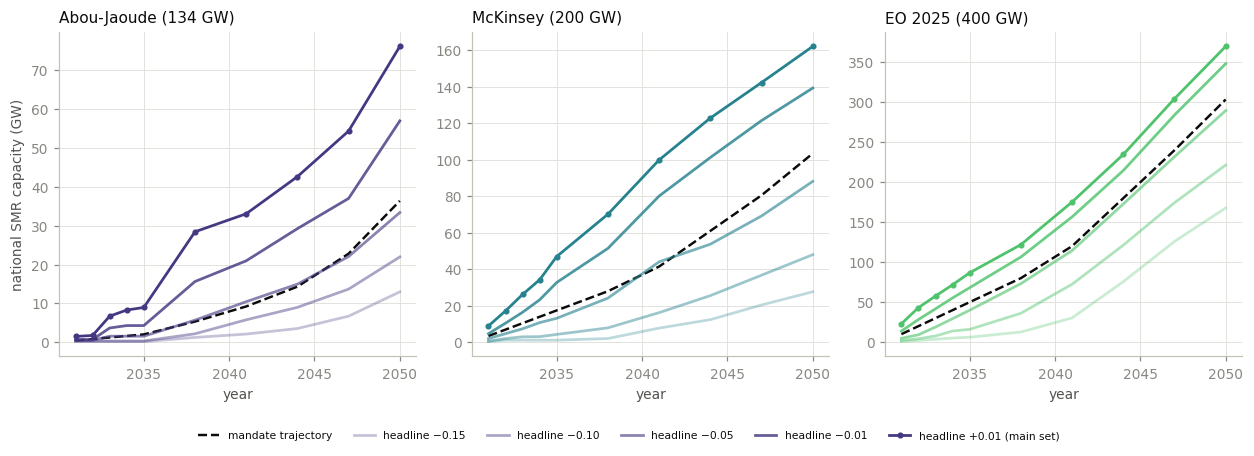

In [7]:
# ---- j01/j02: trajectory ladder panels --------------------------------------------
def ladder_panels(arm, fname):
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9), sharex=True)
    yrs = [t for t in YEARS_RUN if t >= 2026]
    for ax, w in zip(axes, WORLDS):
        tr = TRAJ[w]
        ax.plot(yrs, [tr.get(t, 0.0) / 1000 for t in yrs], color=INK, ls="--",
                lw=1.6, label="mandate trajectory")
        for g in LADDER:
            c = run_of(arm, g, w)
            ax.plot(yrs, [SMR_CAP[c].get(t, 0.0) / 1000 for t in yrs],
                    color=SCHED_C[w], lw=1.8, alpha=RUNG_ALPHA[g],
                    marker="o" if g == "p01" else "", ms=3.0,
                    label=RUNG_LABEL[g])
        ax.set_title(SCHED_LABEL[w])
        ax.set_xlabel("year")
    axes[0].set_ylabel("national SMR capacity (GW)")
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=6, fontsize=7,
               bbox_to_anchor=(0.5, -0.06))
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    savefig(fig, fname)
    plt.show()

ladder_panels("fbBm", "j01_fbBm_trajectory_ladder.png")


saved -> figures\j02_fbCm_trajectory_ladder.png


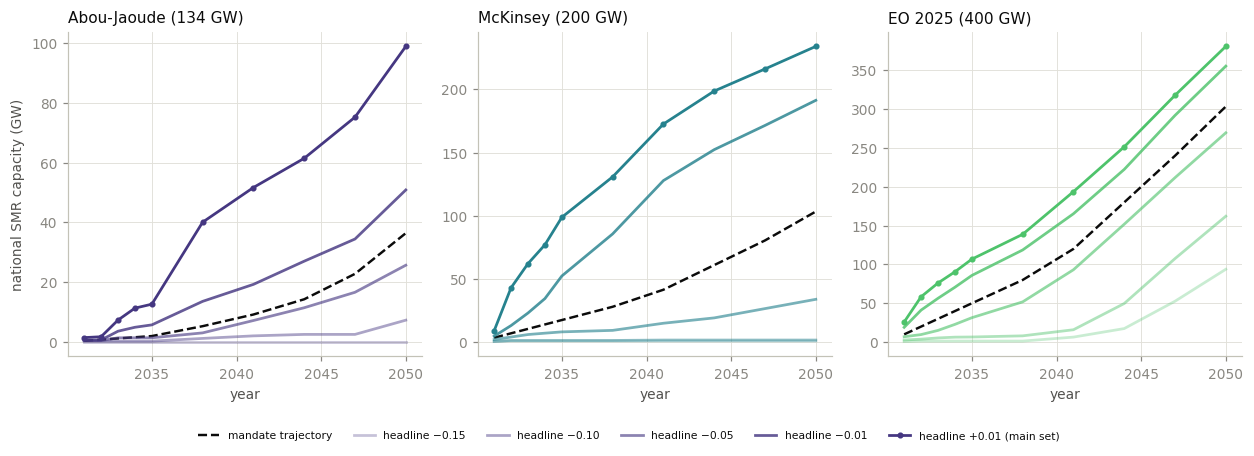

In [8]:
ladder_panels("fbCm", "j02_fbCm_trajectory_ladder.png")


## R3 — Outcomes and the delivery-minimality verdicts

The outcome classification comes from the checks (`delivery_outcomes.csv`;
the tier and outcome conventions are stated there). The sibling (p01) tiers
come from the main set's q02/q03 gap exports through the same `tier_of`
convention.

**Verdict convention (pre-registered).** For each (arm, world) ladder:

- the *deepest delivering rung* is the deepest rung with outcome
  full-delivery;
- the *shallowest failing rung* is the shallowest rung below it without
  full delivery;
- the delivery-minimal uniform rate is bracketed between those two rungs'
  fed rates.

A below-headline rung that still delivers shows the headline was not
delivery-minimal — the t13 uniform-rate overshoot materializing in deployment
space. It never shows the duals were wrong.

In [9]:
def tier_of(sub):
    """Reproduction tier for one case's gap rows (the itcfb_checks convention)."""
    shortfall = (-sub["gap_MW"]).clip(lower=0.0)
    if float(shortfall.max()) <= 5.0 and float(sub["gap_MW"].abs().max()) <= 5.0:
        return "exact"
    gate = sub[(sub["status"] == "rate") | (sub["t"] == 2050)]
    g_short = (-gate["gap_MW"]).clip(lower=0.0)
    tol1 = np.maximum(0.05 * gate["mandate_MW"], 500.0)
    if bool((g_short <= tol1).all()):
        return "reproduces"
    end = gate[gate["t"] == 2050]
    if len(end) and float(-end["gap_MW"].iloc[0]) <= 0.15 * float(end["mandate_MW"].iloc[0]):
        return "partial"
    return "no"

# per-cell tier + outcome + delivered fraction, all 30 ladder cells
cell_rows = []
for arm in ["fbBm", "fbCm"]:
    for w in WORLDS:
        for g in LADDER:
            c = run_of(arm, g, w)
            if g == "p01":
                t_ = tier_of(r02[r02["case"] == c])
                outcome = "full-delivery" if t_ in ("exact", "reproduces") else t_
            else:
                row = OUT_M[OUT_M["case"] == c].iloc[0]
                t_, outcome = row["tier"], row["outcome"]
            frac = float(SMR_CAP[c].get(2050, 0.0)) / float(TRAJ[w].get(2050))
            cell_rows.append(dict(arm=arm, world=w, rung=g, case=c, cut=CUT[g],
                                  fed_mean=round(float(np.mean(list(FED[(w, g)].values()))), 3),
                                  m_monetized=M_MEAN[(w, g)], tier=t_, outcome=outcome,
                                  delivered_frac_2050=round(frac, 4)))
cells = pd.DataFrame(cell_rows)
print(cells.pivot_table(index=["arm", "world"], columns="rung",
                        values="delivered_frac_2050").reindex(columns=LADDER)
      .round(3).to_string())


rung          m15    m10    m05    m01    p01
arm  world                                   
fbBm aj     0.356  0.603  0.917  1.566  2.093
     eo     0.553  0.730  0.954  1.148  1.219
     mck    0.268  0.464  0.852  1.346  1.567
fbCm aj     0.004  0.201  0.706  1.397  2.715
     eo     0.309  0.534  0.888  1.171  1.255
     mck    0.009  0.016  0.328  1.851  2.264


In [10]:
# ---- r03: the delivery-minimality verdicts (the ST9 feed) -------------------------
rows = []
for arm in ["fbBm", "fbCm"]:
    for w in WORLDS:
        sub = cells[(cells["arm"] == arm) & (cells["world"] == w)] \
            .set_index("rung").reindex(LADDER)
        deliver = sub[sub["outcome"] == "full-delivery"]
        deepest = deliver.iloc[0].name if len(deliver) else None
        below = [g for g in LADDER[:LADDER.index(deepest)]] if deepest else LADDER
        shallowest_fail = below[-1] if below else None
        rows.append(dict(
            arm=arm, world=w,
            deepest_delivering_rung=deepest,
            cut_points=CUT.get(deepest) if deepest else None,
            cut_monetized=round(0.9 * CUT[deepest], 3) if deepest else None,
            shallowest_failing_rung=shallowest_fail,
            failing_cut_points=CUT.get(shallowest_fail) if shallowest_fail else None,
            failing_outcome=(sub.loc[shallowest_fail, "outcome"]
                             if shallowest_fail else None),
            delivered_frac_at_fail=(sub.loc[shallowest_fail, "delivered_frac_2050"]
                                    if shallowest_fail else None),
            outcomes_down_ladder=" > ".join(sub["outcome"].loc[LADDER[::-1]]),
        ))
r03 = pd.DataFrame(rows)
r03 = r03.merge(cells[["arm", "world", "rung", "delivered_frac_2050"]]
                .pivot_table(index=["arm", "world"], columns="rung",
                             values="delivered_frac_2050")
                .reindex(columns=LADDER)
                .rename(columns=lambda g: f"frac_{g}").reset_index(),
                on=["arm", "world"])
r03.to_csv(EXPORTS / "r03_minimality_verdicts.csv", index=False)
print(r03.to_string(index=False))

d_ok = r03["deepest_delivering_rung"].value_counts().to_dict()
print(f"\nMINIMALITY READING: deepest delivering rung by ladder: {d_ok}. "
      "A rung below the headline that delivers shows the headline was not "
      "delivery-minimal (the t13 overshoot in deployment space) — "
      "not that the duals were wrong.")


 arm world deepest_delivering_rung  cut_points  cut_monetized shallowest_failing_rung  failing_cut_points       failing_outcome  delivered_frac_at_fail                                                                    outcomes_down_ladder  frac_m15  frac_m10  frac_m05  frac_m01  frac_p01
fbBm    aj                     m01        0.01          0.009                     m05                0.05               partial                  0.9173               full-delivery > full-delivery > partial > under-delivery > under-delivery    0.3562    0.6032    0.9173    1.5661    2.0931
fbBm   mck                     m01        0.01          0.009                     m05                0.05               partial                  0.8522               full-delivery > full-delivery > partial > under-delivery > under-delivery    0.2679    0.4642    0.8522    1.3462    1.5666
fbBm    eo                     m01        0.01          0.009                     m05                0.05 delayed-start-recover   

saved -> figures\j03_delivery_fraction_ladder.png


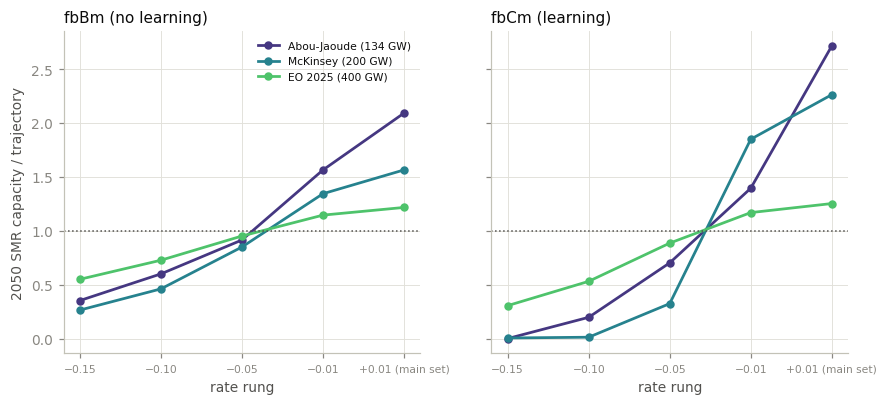

In [11]:
# ---- j03: delivered fraction down the ladder --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), sharey=True)
x = np.arange(len(LADDER))
for ax, arm in zip(axes, ["fbBm", "fbCm"]):
    for w in WORLDS:
        sub = cells[(cells["arm"] == arm) & (cells["world"] == w)] \
            .set_index("rung").reindex(LADDER)
        ax.plot(x, sub["delivered_frac_2050"], color=SCHED_C[w], lw=1.8,
                marker="o", ms=4.5, label=SCHED_LABEL[w])
    ax.axhline(1.0, color=MUTED, lw=1.0, ls=":")
    ax.set_xticks(x)
    ax.set_xticklabels([RUNG_LABEL[g].replace("headline ", "") for g in LADDER],
                       fontsize=7)
    ax.set_title("fbBm (no learning)" if arm == "fbBm" else "fbCm (learning)")
    ax.set_xlabel("rate rung")
axes[0].set_ylabel("2050 SMR capacity / trajectory")
axes[0].legend(fontsize=7)
savefig(fig, "j03_delivery_fraction_ladder.png")
plt.show()


## R4 — The deployment-vs-rate cliff

The combined demand curve extends the main set's q06 export: the fbR flat
anchors (a flat credit for both technologies), the schedule-rate points of
the main set, and the 24 minus rungs. The x-axis is the monetized mean rate
over the rate years, `mean_t(itc_frac) x 0.9` — the q06 convention. Vertical
ticks mark each world's mean monetized-parity rate.

Caveat (carried from the main set): the flat anchors bound the schedule
points, they do not interpolate them — a flat both-technology credit and a
time-varying SMR-only schedule are different instruments.

In [12]:
new_rows = []
for r in cells.itertuples():
    if r.rung == "p01":
        continue     # already in q06 as schedule-fbB / schedule-fbC
    new_rows.append(dict(kind=f"schedule-{r.arm}", case=r.case, world=r.world,
                         m_monetized=r.m_monetized,
                         smr_2050_GW=round(float(SMR_CAP[r.case].get(2050, 0.0)) / 1000, 2),
                         large_2050_GW=round(float(LG_CAP[r.case].get(2050, 0.0)) / 1000, 2),
                         nuclear_2050_GW=round((float(SMR_CAP[r.case].get(2050, 0.0))
                                                + float(LG_CAP[r.case].get(2050, 0.0)))
                                               / 1000, 2),
                         set="itcfbm", rung=r.rung))
q06x = Q06.copy()
q06x["set"] = "itcfb"
q06x["rung"] = np.where(q06x["kind"] == "flat-anchor", "flat", "p01")
r04 = pd.concat([q06x, pd.DataFrame(new_rows)], ignore_index=True)
r04.to_csv(EXPORTS / "r04_rate_deployment.csv", index=False)
assert len(r04) == len(Q06) + 24
print(r04.to_string(index=False))


         kind           case world  m_monetized  smr_2050_GW  large_2050_GW  nuclear_2050_GW    set rung
  flat-anchor       fbR_none   eia        0.000         0.00          94.11            94.11  itcfb flat
  flat-anchor      fbR_itc30   eia        0.270         0.00          94.11            94.11  itcfb flat
  flat-anchor      fbR_itc50   eia        0.450         9.79          94.11           103.89  itcfb flat
 schedule-fbB    fbB_eia_p50   eia        0.543        54.22          94.11           148.33  itcfb  p01
 schedule-fbB     fbB_aj_p50    aj        0.569        76.19          94.11           170.29  itcfb  p01
 schedule-fbB   fbB_iaea_p50  iaea        0.648       123.16          94.11           217.27  itcfb  p01
 schedule-fbB    fbB_mck_p50   mck        0.624       161.98          94.11           256.09  itcfb  p01
 schedule-fbB  fbB_cop28_p50 cop28        0.671       264.61          94.11           358.72  itcfb  p01
 schedule-fbB     fbB_eo_p50    eo        0.622       3

saved -> figures\j04_deployment_vs_rate_cliff.png


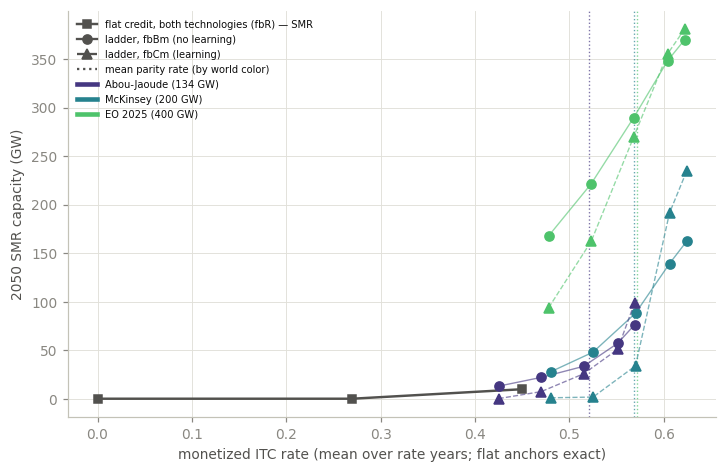

In [13]:
# ---- j04: the cliff figure --------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 4.8))
anch = r04[r04["kind"] == "flat-anchor"].sort_values("m_monetized")
ax.plot(anch["m_monetized"], anch["smr_2050_GW"], color=MUTED, lw=1.6, marker="s",
        ms=5, label="flat credit, both technologies (fbR) — SMR")
PAR_MEAN = {w: round(float(PARITY[PARITY["world"] == w]["i_par"].mean()) * (1 - PEN), 3)
            for w in WORLDS}
for w in WORLDS:
    ax.axvline(PAR_MEAN[w], color=SCHED_C[w], lw=0.9, ls=":", alpha=0.7)
for arm, mk in [("fbBm", "o"), ("fbCm", "^")]:
    for w in WORLDS:
        sub = cells[(cells["arm"] == arm) & (cells["world"] == w)] \
            .set_index("rung").reindex(LADDER)
        gw = [float(SMR_CAP[run_of(arm, g, w)].get(2050, 0.0)) / 1000 for g in LADDER]
        ax.plot(sub["m_monetized"], gw, color=SCHED_C[w], lw=0.9, alpha=0.6,
                ls="-" if arm == "fbBm" else "--")
        ax.plot(sub["m_monetized"], gw, color=SCHED_C[w], marker=mk, ms=6, ls="")
from matplotlib.lines import Line2D
extra = [Line2D([], [], marker="o", ls="-", color=MUTED, label="ladder, fbBm (no learning)"),
         Line2D([], [], marker="^", ls="--", color=MUTED, label="ladder, fbCm (learning)"),
         Line2D([], [], ls=":", color=MUTED, label="mean parity rate (by world color)")]
for w in WORLDS:
    extra.append(Line2D([], [], marker="s", ms=0, lw=3, color=SCHED_C[w],
                        label=SCHED_LABEL[w]))
h_, l_ = ax.get_legend_handles_labels()
ax.legend(handles=h_ + extra, fontsize=6.5, loc="upper left")
ax.set_xlabel("monetized ITC rate (mean over rate years; flat anchors exact)")
ax.set_ylabel("2050 SMR capacity (GW)")
savefig(fig, "j04_deployment_vs_rate_cliff.png")
plt.show()


### j06 — The cliff on the statutory basis, new nuclear only (main-text panel)

Promoted to main-text Fig 5c on 2026-08-24 (team review; an explicit
one-exhibit reversal of the delivery-to-SI demotion — the validation exhibits
stay in the SI). Two changes against j04, both team rulings: (1) **new nuclear
only**, so every point shares the no-credit baseline — exact, because large
additions are credit-invariant in every run (the r06 zero-substitution
result, asserted); (2) the x axis is the **statutory rate on the model
convention** (monetized / (1 − PEN)), the same basis as Fig 5a, so the flat
anchors sit at their familiar 30% and 50% and the 48E band overlays exactly
as in that panel. The cell reads the committed r04 export, so it re-runs
without the h5 drive.

In [ ]:
# ---- j06: the cliff, statutory basis, new nuclear only (main-text Fig 5c; 2026-08-24) -----------
j06 = pd.read_csv(EXPORTS / "r04_rate_deployment.csv")
assert j06["large_2050_GW"].nunique() == 1          # large never moves with the credit
j06["new_GW"] = j06["smr_2050_GW"]                  # so new nuclear = SMR exactly
j06["i_stat"] = j06["m_monetized"] / (1 - PEN)      # statutory rate, model convention
J06_LAB = {"eia": "EIA AEO high", "aj": "Abou-Jaoude", "iaea": "IAEA high",
           "mck": "McKinsey", "cop28": "COP28", "eo": "EO 2025"}

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.axvspan(0.30, 0.50, color=ps.NEUTRAL, alpha=0.55, zorder=1)
ax.text(0.40, 220, "48E range\n30–50%", fontsize=7.5, color=MUTED,
        ha="center", va="top")

flat = j06[j06["kind"] == "flat-anchor"].sort_values("i_stat")
assert [round(v, 2) for v in flat["i_stat"]] == [0.0, 0.30, 0.50]
ax.plot(flat["i_stat"], flat["new_GW"], marker="s", ms=5, lw=1.6, color=INK,
        zorder=4, label="flat credit (eia world)")

for w in WORLDS:                                    # the three minus-probe ladder worlds
    fbc = j06[j06["kind"].isin(["schedule-fbCm", "schedule-fbC"])
              & (j06["world"] == w)].sort_values("i_stat")
    ax.plot(fbc["i_stat"], fbc["new_GW"], marker="o", ms=5, lw=1.8,
            color=SCHED_C[w], zorder=5, label=J06_LAB[w])
    fbb = j06[j06["kind"].isin(["schedule-fbBm", "schedule-fbB"])
              & (j06["world"] == w)].sort_values("i_stat")
    ax.plot(fbb["i_stat"], fbb["new_GW"], lw=1.1, ls="--", alpha=0.45,
            color=SCHED_C[w], zorder=3)
for w in ["eia", "iaea", "cop28"]:                  # headline-only worlds
    pt = j06[(j06["kind"] == "schedule-fbC") & (j06["world"] == w)]
    ax.scatter(pt["i_stat"], pt["new_GW"], marker="o", s=30, color=SCHED_C[w],
               zorder=5, label=J06_LAB[w] + " (headline only)")
ax.plot([], [], color=MUTED, lw=1.8, marker="o", ms=5, label="with learning (fbC)")
ax.plot([], [], color=MUTED, lw=1.1, ls="--", alpha=0.6, label="no learning (fbB)")
ax.set_xlabel("ITC rate (model convention; same basis as Fig 5a)")
ax.set_ylabel("new nuclear 2050 capacity (GW)")
ax.set_xlim(-0.02, 0.79)
ax.legend(fontsize=7, ncol=2, loc="upper left", handletextpad=0.5,
          columnspacing=1.0)
fig.tight_layout()
savefig(fig, "j06_new_nuclear_cliff.png")
plt.show()

## R5 — The ignition cushion (fbCm vs fbBm)

The learning arm answers: what does endogenous learning add below the convex
minimum? Above the cliff, learning can add capacity (a cushion: builds lower
cost, which brings more builds). Below the cliff the same feed-back works in
reverse (a drag: few builds keep cost high, which keeps builds few). The
cushion is the fbCm minus fbBm delivered fraction per (world, rung). The
first-build year tests for the delayed-start signature (`fbC_eia` in the main
set started late and recovered).

In [14]:
cush_rows = []
for w in WORLDS:
    for g in LADDER:
        fb = cells[(cells["arm"] == "fbBm") & (cells["world"] == w)
                   & (cells["rung"] == g)].iloc[0]
        fc = cells[(cells["arm"] == "fbCm") & (cells["world"] == w)
                   & (cells["rung"] == g)].iloc[0]
        first_b = OUT_M[OUT_M["case"] == fb.case]["first_build_year"].iloc[0] \
            if g != "p01" else 2031
        first_c = OUT_M[OUT_M["case"] == fc.case]["first_build_year"].iloc[0] \
            if g != "p01" else 2031
        cush_rows.append(dict(world=w, rung=g, cut=CUT[g],
                              frac_fbBm=fb.delivered_frac_2050,
                              frac_fbCm=fc.delivered_frac_2050,
                              cushion=round(fc.delivered_frac_2050
                                            - fb.delivered_frac_2050, 4),
                              first_build_fbBm=first_b, first_build_fbCm=first_c,
                              outcome_fbBm=fb.outcome, outcome_fbCm=fc.outcome))
r05 = pd.DataFrame(cush_rows)
r05.to_csv(EXPORTS / "r05_ignition_cushion.csv", index=False)
print(r05.to_string(index=False))


world rung   cut  frac_fbBm  frac_fbCm  cushion  first_build_fbBm  first_build_fbCm          outcome_fbBm   outcome_fbCm
   aj  m15  0.15     0.3562     0.0039  -0.3523              2031              2031        under-delivery under-delivery
   aj  m10  0.10     0.6032     0.2009  -0.4023              2031              2031        under-delivery under-delivery
   aj  m05  0.05     0.9173     0.7055  -0.2118              2031              2031               partial under-delivery
   aj  m01  0.01     1.5661     1.3969  -0.1692              2031              2031         full-delivery  full-delivery
   aj  p01 -0.01     2.0931     2.7154   0.6223              2031              2031         full-delivery  full-delivery
  mck  m15  0.15     0.2679     0.0093  -0.2586              2031              2031        under-delivery under-delivery
  mck  m10  0.10     0.4642     0.0164  -0.4478              2031              2031        under-delivery under-delivery
  mck  m05  0.05     0.8522     

saved -> figures\j05_ignition_cushion.png


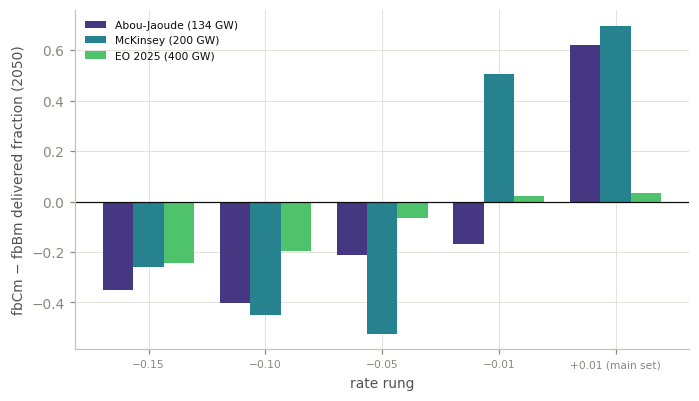

In [15]:
# ---- j05: the cushion by rung -----------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.0))
x = np.arange(len(LADDER))
width = 0.26
for k, w in enumerate(WORLDS):
    sub = r05[r05["world"] == w].set_index("rung").reindex(LADDER)
    ax.bar(x + (k - 1) * width, sub["cushion"], width=width, color=SCHED_C[w],
           label=SCHED_LABEL[w])
ax.axhline(0.0, color=INK, lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([RUNG_LABEL[g].replace("headline ", "") for g in LADDER],
                   fontsize=7)
ax.set_xlabel("rate rung")
ax.set_ylabel("fbCm − fbBm delivered fraction (2050)")
ax.legend(fontsize=7)
savefig(fig, "j05_ignition_cushion.png")
plt.show()


## R6 — Substitution and context

The credit does not force the SMR: ReEDS picks its own winner. New large
builds after 2030 are reported per run, with the world's base-run large fleet
as the baseline. The ITC payment magnitudes give budget context: payments
scale with builds, so the deep rungs pay little — under-delivery is cheap,
which is exactly the fiscal face of the cliff.

In [16]:
rows = []
for c in ALL_RUNS:
    m = META.get(c, {})
    w_ = m.get("world", c.split("_")[1] if c in SIBLING_CASES else "")
    rows.append(dict(case=c,
                     arm=m.get("arm", c.split("_")[0]),
                     rung=m.get("rung", "p01" if c in SIBLING_CASES else "flat"),
                     world=w_,
                     smr_2050_GW=round(float(SMR_CAP[c].get(2050, 0.0)) / 1000, 2),
                     large_2050_GW=round(float(LG_CAP[c].get(2050, 0.0)) / 1000, 2),
                     new_large_post2030_GW=round(float(LG_NEW[c].sum()) / 1000, 2)))
r06 = pd.DataFrame(rows)
base_lg = {w: round(float(LG_CAP[BASE_OF_WORLD[w]].get(2050, 0.0)) / 1000, 2)
           for w in WORLDS}
r06["base_large_2050_GW"] = r06["world"].map(base_lg)
r06.to_csv(EXPORTS / "r06_substitution.csv", index=False)
n_sub = int((r06["new_large_post2030_GW"] > 0).sum())
print(r06.to_string(index=False))
print(f"\nruns with new large builds after 2030: {n_sub}")


          case  arm rung world  smr_2050_GW  large_2050_GW  new_large_post2030_GW  base_large_2050_GW
 fbBm01_aj_p50 fbBm  m01    aj        57.00          94.11                    0.0               94.11
fbBm01_mck_p50 fbBm  m01   mck       139.19          94.11                    0.0               94.11
 fbBm01_eo_p50 fbBm  m01    eo       348.24          94.11                    0.0               94.11
 fbBm05_aj_p50 fbBm  m05    aj        33.39          94.11                    0.0               94.11
fbBm05_mck_p50 fbBm  m05   mck        88.12          94.11                    0.0               94.11
 fbBm05_eo_p50 fbBm  m05    eo       289.52          94.11                    0.0               94.11
 fbBm10_aj_p50 fbBm  m10    aj        21.96          94.11                    0.0               94.11
fbBm10_mck_p50 fbBm  m10   mck        48.00          94.11                    0.0               94.11
 fbBm10_eo_p50 fbBm  m10    eo       221.44          94.11                    0.0 

## R7 — Caveats and output manifest

Caveats, in reading order:

1. **The eo rate schedule is back-loaded** (the fed rates rise 2044-2050).
   A 2050-only delivery metric can hide a mid-course sag, so the tier gates
   apply to every rate year, and `r02_delivery_gaps.csv` keeps the per-year
   gaps.
2. **The x-axis of the cliff figure is a mean rate.** Schedule credits vary
   by year; the mean is a display convention (the q06 convention), not an
   instrument. The flat fbR anchors are exact points of a different
   instrument (both technologies, all years) and bound the curve from below.
3. **The solve is sequential and myopic.** Investors see lagged costs, so a
   delayed-start-recover outcome under learning mirrors the main set's
   fbC_eia nuance, and strict monotonicity of delivery in the rate is not
   provable (the translim precedent).
4. **No duals exist in the minus runs by design** (no mandate). Nothing here
   re-prices the schedules; the runs test delivery only.
5. **Claim separation** (pre-registered, restated): a below-headline rung
   that delivers shows the uniform headline rate was not delivery-minimal.
   It does not show the duals were wrong.

Outputs:

- `exports/r00_run_inventory.csv` — the 33-run inventory with rates.
- `exports/r01_rate_ladder.csv` — fed rates by rate year + parity placement.
- `exports/r02_delivery_gaps.csv` — per-year gaps, all 30 ladder cells.
- `exports/r03_minimality_verdicts.csv` — the delivery-minimality verdicts
  (the ST9 feed).
- `exports/r04_rate_deployment.csv` — the combined q06-extension table.
- `exports/r05_ignition_cushion.csv` — fbCm vs fbBm by rung.
- `exports/r06_substitution.csv` — large-reactor context.
- `figures/j01, j02` — trajectory ladders; `j03` — delivered fractions;
  `j04` — the deployment-vs-rate cliff; `j05` — the ignition cushion;
  `j06` — the cliff on the statutory basis, new nuclear only (main-text
  Fig 5c).

In [17]:
manifest = sorted(p.name for p in EXPORTS.glob("r0*.csv")) \
    + sorted(p.name for p in FIGURES.glob("j0*.png"))
print("\n".join(manifest))
print("\ndone.")


r00_run_inventory.csv
r01_rate_ladder.csv
r02_delivery_gaps.csv
r03_minimality_verdicts.csv
r04_rate_deployment.csv
r05_ignition_cushion.csv
r06_substitution.csv
j01_fbBm_trajectory_ladder.png
j02_fbCm_trajectory_ladder.png
j03_delivery_fraction_ladder.png
j04_deployment_vs_rate_cliff.png
j05_ignition_cushion.png

done.
